# Introduction to Signal Analysis

## 1. Signals in Physics and Electronics

In many experiments we measure quantities that **vary in time**.

Examples:

* Voltage from a sensor
* Current in a circuit
* Sound recorded by a microphone
* Oscillations of a mechanical system

Mathematically we represent these as

$$
x(t)
$$

called a **signal**.

Examples:

| Signal                | Meaning           |
| --------------------- | ----------------- |
| voltage (V(t))        | electrical signal |
| current (I(t))        | circuit response  |
| sound pressure (p(t)) | acoustic signal   |
| displacement (x(t))   | mechanical motion |

<div style="border:6px solid #007acc; background-color:#bbb; color:#000; border-radius: 5px; padding: 10px;">

Our main questions are:

1. **What frequencies exist in the signal?**
2. **How does a system modify a signal?**
3. **How do signals combine?**

To answer these questions we use three fundamental tools:

| **Tool**              | **Purpose**                   |
| ----------------- | ------------------------- |
| **Fourier transform** | **reveals frequency content** |
| **Convolution**       | **describes system response** |
| **Laplace transform** | **analyzes system dynamics**  |

</div>


# 2. Time Domain vs Frequency Domain

Signals can be described in two equivalent ways.

### Time domain

Signal as a function of time

$$
x(t)
$$

Example: voltage measured by an oscilloscope.

### Frequency domain

Signal expressed as a combination of sinusoidal waves

$$
X(f)
$$

This representation tells us **which frequencies are present in the signal**.


# Example

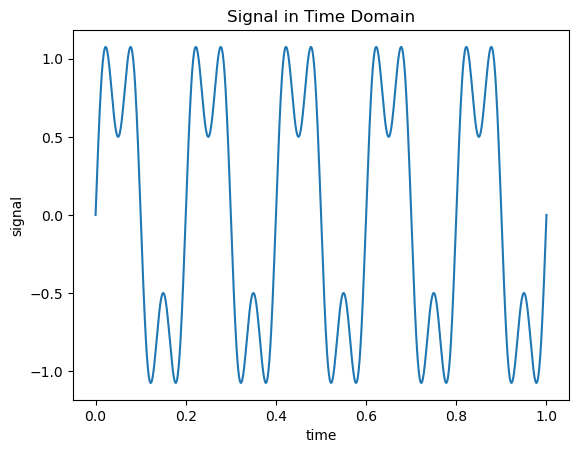

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0,1,1000)

signal = np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*15*t)

plt.plot(t,signal)
plt.xlabel("time")
plt.ylabel("signal")
plt.title("Signal in Time Domain")
plt.show()

This signal contains two frequencies:

* **5 Hz**
* **15 Hz**

But this is not obvious from the time plot alone.


# Frequency spectrum

We use the **Fourier transform** to reveal the frequency components.

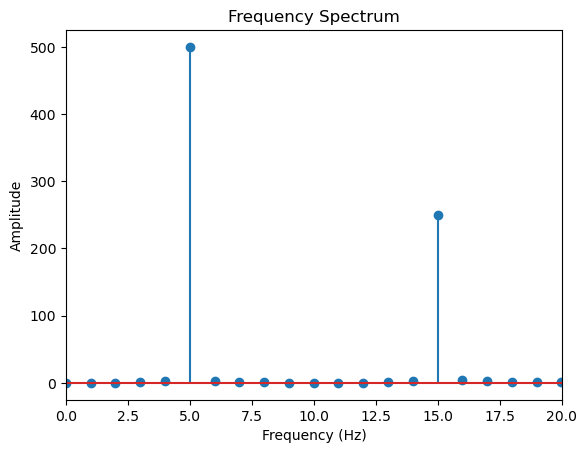

In [2]:
from scipy.fft import fft, fftfreq

N = len(t)
dt = t[1]-t[0]

freq = fftfreq(N,dt)
S = fft(signal)

plt.stem(freq[:N//2], np.abs(S[:N//2])) #see the difference between stem and plot
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum")
plt.xlim(0,20)
plt.show()

Now we clearly see peaks at:

* **5 Hz**
* **15 Hz**


# 3. Fourier Series (Periodic Signals)

If a signal is **periodic**, it can always be written as a sum of sine and cosine waves.

This is called the **Fourier series**.

$$
f(t) = a_0 +
\sum_{n=1}^{\infty}
\left(
a_n \cos(n\omega t)
+
b_n \sin(n\omega t)
\right)
$$

Meaning:

> Any periodic signal can be decomposed into sinusoidal oscillations.

---

# Example: Square Wave

A square wave looks very different from a sine wave.

However it can be approximated using a **sum of harmonics**.

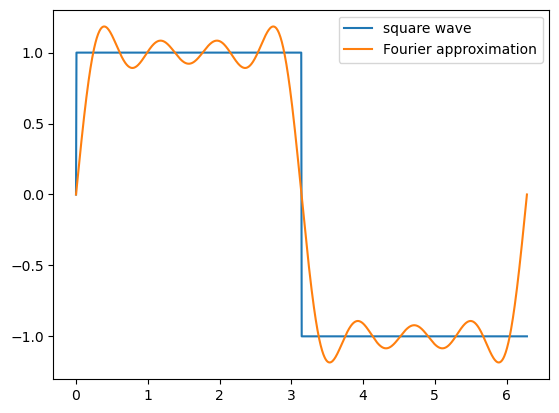

In [3]:
t = np.linspace(0,2*np.pi,1000)

square = np.sign(np.sin(t))

approx = np.sin(t)
approx += 1/3*np.sin(3*t)
approx += 1/5*np.sin(5*t)
approx += 1/7*np.sin(7*t)

approx *= 4/np.pi

plt.plot(t,square,label="square wave")
plt.plot(t,approx,label="Fourier approximation")
plt.legend()
plt.show()

This demonstrates an important idea:

> Complex signals are combinations of simple oscillations.


# 4. Fourier Transform (Non-Periodic Signals)

The Fourier series works for **periodic signals**.

But many real signals are not periodic.

Examples:

* short pulses
* noise
* transient signals

For these we use the **Fourier transform**

$$
X(f) =
\int_{-\infty}^{\infty}
x(t)e^{-i2\pi ft} dt
$$

It converts

**time → frequency representation**.


# Time–frequency relation

A very important principle:

### Short signals contain many frequencies.

Example:

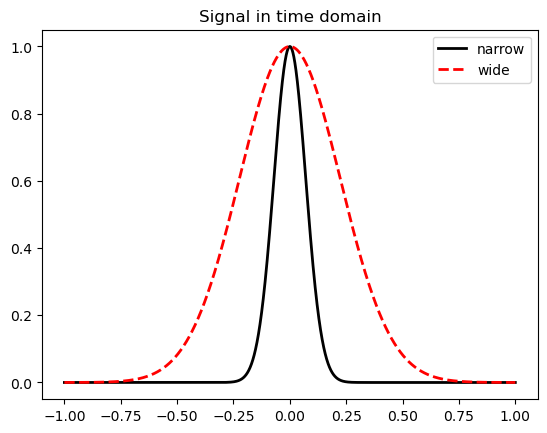

In [4]:
t = np.linspace(-1,1,4000)

pulse_narrow = np.exp(-100*t**2)
pulse_wide   = np.exp(-10*t**2)

plt.plot(t,pulse_narrow,'-k',lw=2,label='narrow')
plt.plot(t,pulse_wide,'--r',lw=2,label='wide')
plt.title("Signal in time domain")
plt.legend()
plt.show()

Now compute its spectrum.

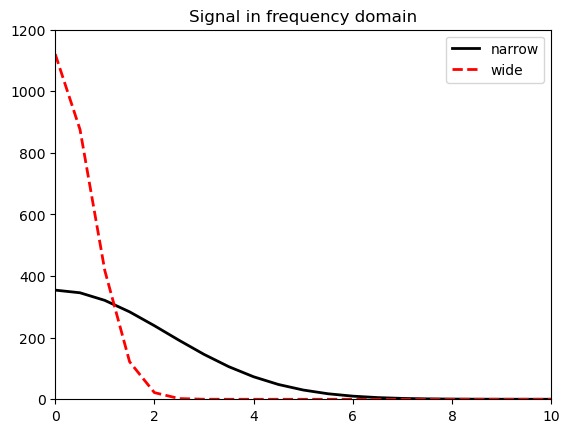

In [5]:
S_narrow = fft(pulse_narrow)
S_wide   = fft(pulse_wide)

freq = fftfreq(len(t),t[1]-t[0])

plt.plot(freq[:2000],np.abs(S_narrow[:2000]),'-k',lw=2,label='narrow')
plt.plot(freq[:2000],np.abs(S_wide[:2000]),'--r',lw=2,label='wide')

plt.title("Signal in frequency domain")
plt.xlim(0,10)
plt.ylim(0,1200)
plt.legend()
plt.show()

Observation:

> **Short signals produce wide frequency spectra.**

<u>This is a fundamental property of signal analysis.</u>

> **Note:** Fourier transform produces positive and negative frequencies. The reason is that a harmonic real function are made of both positive and negative frequencies.
> $$ \sin(\omega t) = \frac{e^{j\,\omega t} - e^{-j\,\omega t}}{2j} $$
> $$ \cos(\omega t) = \frac{e^{j\,\omega t} + e^{-j\,\omega t}}{2} $$
> Here $\omega$ and $-\omega$ have similar contribution thus knowing the spectrum in positive frequencies gives complete information for the negative part (due to symmetry). However, one needs or obtain both negative and positive frequency solutions during Fourier transform, because their sum produce a real function (e.g. harmonic function)


<div style="border:6px solid #007acc; background-color:#bbb; color:#000; border-radius: 5px; padding: 10px;">

## **Fourier Transform and the Invers Fourier Transform**

Fourier transform of a function $f(t)$ is ($t\to \omega$):

$$ F(\omega) = \int\limits_{-\infty}^{\infty} f(t)\, e^{-j\omega t}\, dt , $$


whereas, its inverse transform is ($\omega\to t$):

$$f(t) = \frac{1}{2\pi} \int\limits_{-\infty}^{\infty} F(\omega)\, e^{j\omega t}\, d\omega $$


### **Fondamental Properties of the Fourier Transform**
1. **Linearity**
   - If $f(t)$ and $g(t)$ are two functions, then:
   $$ \mathcal{F}\{ a\, f(t) + b\, g(t) \} = a\, F(\omega) + b\, G(\omega) $$
   where $\mathcal{F}$ is the Fourier transforms.

2. **Time Shift and Frequency Shift**
   - A signal that is narrower in the time domain is wider in the frequency domain, and vice versa.

3. **Convolution**
   - Convolution of two functions in time domain becomes multiplication of their fourier transforms in the frequency domain:
   $$\mathcal{F}\{ f(t) * g(t) \} = F(\omega)\, G(\omega)$$

4. **Derivative and Integration**
   - Fourier transform changes derivative of the function into its transform times the frequency:
   $$ \mathcal{F} \left\{ \frac{d}{dt} f(t) \right\} = j\, \omega\, F(\omega) $$

5. **Time Shift**
   - Time shift with $t_0$ results in multiplcation of the transform with an exponential term in the frequency domain:
   $$ \mathcal{F}\{ f(t - t_0) \} = e^{-j\, \omega\, t_0}\, F(\omega) $$

6. **Time Scaling**
   - Scaling time by $a$ results in:
   $$ \mathcal{F}\{ f(a\,t) \} = \frac{1}{|a|}\, F(\omega/a) $$

---

### **Table of the Fourier Transform of commen frunctions**

| Functon $f(t)$ | Fourier Transform $F(\omega)$ |
|-------------------------------|---------------------------------|
| $\delta(t)$ (Dirac Delta-function) | $1$ |
| $1$ (Constant function) | $ 2\pi \delta(\omega) $ |
| $ e^{-at} u(t) $, $ a > 0 $ | $ \frac{1}{a + j\omega} $ |
| $ \cos(\omega_0 t) $ | $ \pi [\delta(\omega - \omega_0) + \delta(\omega + \omega_0)] $ |
| $ \sin(\omega_0 t) $ | $ j\pi [\delta(\omega - \omega_0) - \delta(\omega + \omega_0)] $ |
| Square wave $ \mathsf{rect}(t/T) $ | $ T \text{sinc}(T\omega) $ |
| Gaussian $ e^{-t^2} $ | $ \sqrt{\pi} e^{-\omega^2/4} $ |


# **Fourier Transform Examples**

### **Example 1: Square Wave**
$$
f(t) =
\begin{cases} 
1, & |t| \leq \tau/2 \\
0, & \text{otherwise}
\end{cases}
$$

Want to find **Fourier Transform**:

$$ F(\omega) = \int_{-\infty}^{\infty} f(t) e^{-j\omega t} dt$$

Replace $f(t)$ in the integral:
$$ F(\omega) = \int_{-\tau/2}^{\tau/2} e^{-j\omega t} dt$$

This integral is a simple exponential:

$$ F(\omega) = \left[ \frac{e^{-j\omega t}}{-j\omega} \right]_{-\tau/2}^{\tau/2}$$

Replace the boundary:
$$F(\omega) = \frac{e^{-j\omega (\tau/2)} - e^{j\omega (\tau/2)}}{-j\omega}$$

Utilize the complex sin formula:
$$ e^{-j\theta} - e^{j\theta} = -2j \sin(\theta) $$

$$ F(\omega) = \frac{-2j \sin(\omega \tau /2)}{-j\omega}$$

We thus onbtain:
$$ F(\omega) = \tau \text{sinc}(\omega \tau /2)$$

where **sinc(x)** is:
$$ \text{sinc}(x) = \frac{\sin(x)}{x}$$

---

### **Example 2: Exponential Signal**
$$ f(t) = e^{-at} \theta(t), \quad a > 0 $$
where **$\theta(t)$ is the Heaviside function** which is $\theta(t)=0$ for $t<0$ and $\theta(t)=1$ for $t>0$.
$$ F(\omega) = \int_{-\infty}^{\infty} e^{-at} \theta(t) e^{-j\omega t} dt $$

Because of the $\theta(t)$ the integral becomes:
$$ F(\omega) = \int_{0}^{\infty} e^{-(a + j\omega)t} dt $$

This is an integral of the form:
$$ \int e^{-\lambda t} dt = \frac{e^{-\lambda t}}{-\lambda} $$

where $\lambda = a + j\omega$. Apply the boundary:
$$ F(\omega) = \left[ \frac{e^{-(a + j\omega)t}}{-(a + j\omega)} \right]_{0}^{\infty} $$

In $t = \infty$, the exponential become zero, and in $t = 0$ thus:
$$ F(\omega) = \frac{1}{a + j\omega} $$

The Fourier transform for the exponential function is:
$$ F(\omega) = \frac{1}{a + j\omega}, \quad a > 0 $$

---

### **Example 3: Sine or Cosine Functions**
Take function:
$$ f(t) = \cos(\omega_0 t) $$

Its Fourier transform is:
$$ F(\omega) = \int_{-\infty}^{\infty} \cos(\omega_0 t) e^{-j\omega t} dt $$

Utilize Euler's formula:
$$ \cos(\omega_0 t) = \frac{e^{j\omega_0 t} + e^{-j\omega_0 t}}{2} $$
Therefore:
$$ F(\omega) = \int_{-\infty}^{\infty} \frac{e^{j\omega_0 t} + e^{-j\omega_0 t}}{2} e^{-j\omega t} dt $$

distribute the exponentials:
$$ F(\omega) = \frac{1}{2} \int_{-\infty}^{\infty} e^{-j(\omega - \omega_0) t} dt + \frac{1}{2} \int_{-\infty}^{\infty} e^{-j(\omega + \omega_0) t} dt $$

Knowing that:
$$ \int_{-\infty}^{\infty} e^{-j\alpha t} dt = 2\pi \delta(\alpha) $$

Therefore:
$$ F(\omega) = \frac{1}{2} \left[ 2\pi \delta(\omega - \omega_0) + 2\pi \delta(\omega + \omega_0) \right] $$

The final answer is:
$$ F(\omega) = \pi \left[ \delta(\omega - \omega_0) + \delta(\omega + \omega_0) \right] $$

**Interpretation**: Fourier transform of a sine function is **two Dirac delta function** in $\pm \omega_0$, which shows that sine signal has only **two frequency components**.

### **Example 4: Gaussian Function**
Gaussian function is an interesting case because its **Fourier transform is again a Gaussian function**.
$$ f(t) = e^{-a t^2}, \quad a > 0 $$
We would like to compute:
$$ F(\omega) = \int_{-\infty}^{\infty} e^{-a t^2} e^{-j\omega t} dt $$
Combine the exponents:
$$ F(\omega) = \int_{-\infty}^{\infty} e^{-a t^2 - j\omega t} dt $$

By making the squares terms find:
$$ a t^2 + j\omega t = a \left( t^2 + \frac{j\omega}{a} t \right) $$

By adding and subtracting $\left(\frac{j\omega}{2a}\right)^2$:
$$ a \left(t + \frac{j\omega}{2a} \right)^2 - \frac{\omega^2}{4a} $$

Recreate the exponential function:
$$ e^{-a t^2 - j\omega t} = e^{-a \left( t + \frac{j\omega}{2a} \right)^2} e^{-\frac{\omega^2}{4a}} $$

First integral is a standard Gaussian integral:
$$ \int_{-\infty}^{\infty} e^{-a(t+b)^2} dt = \sqrt{\frac{\pi}{a}} $$

Final answer is:
$$ F(\omega) = \sqrt{\frac{\pi}{a}} e^{-\frac{\omega^2}{4a}} $$

**Result**: **Fourier transform of a Gaussian is another Gaussian!** This property makes Gaussian function special and with many applications in signal processing theory.

---

### **Example 5: Dirac Delta Function**
Dirac delta function is a special of a mathematical distribution function that has **a very simple transformation**.
$$ f(t) = \delta(t) $$

Its Fourier transform is given by:
$$ F(\omega) = \int_{-\infty}^{\infty} \delta(t) e^{-j\omega t} dt $$
From delta-function properties we find:
$$ \int_{-\infty}^{\infty} \delta(t) g(t) dt = g(0) $$

replace $g(t) = e^{-j\omega t}$:
$$ F(\omega) = e^{-j\omega \cdot 0} = 1 $$

**Result**:
$$ F(\omega) = 1 $$

Therefore, Fourier transform of an **impuls Dirac delta-function is a constan signal in the frequency domain**. This recalls our intuition that a narrow impuls contains all frequencies in equal amount.

</div>





# 5. Convolution and System Response

When a signal passes through a system (for example an electronic circuit), the output is modified.

Mathematically this process is described by **convolution**.

If

* (x(t)) is the input signal
* (h(t)) is the system response

then the output is

$$
y(t) = x(t) * h(t)
$$

**where ( * ) denotes convolution.**


# Example: RC Circuir Response

Suppose an RC circuit that has a time constant $\tau=R\,C=1$ s (where $C$ is the capacitor and $R$ the resistor values). Suppose that the input on the circuit is $x(t)$ that stimulates the circuit. The RC circuuit response will be $h=e^{-t/\tau}=e^{-t}$. Therefore, the output of the circuit will be $y(t)$ given by the convolution of input with the response function. See the code.



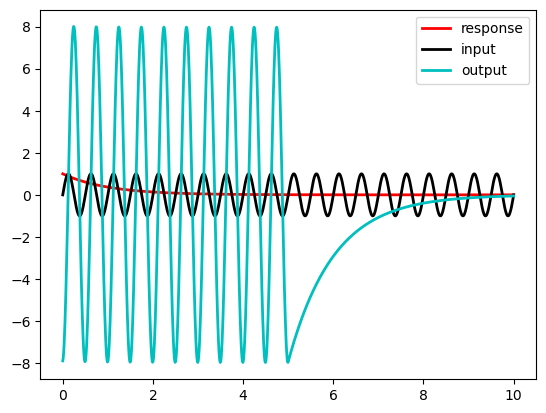

In [6]:
t = np.linspace(0,10,1000)

x = np.sin(2*np.pi*2*t)

h = np.exp(-t)

y = np.convolve(x,h,mode='same')

plt.plot(t,h,'-r',lw=2,label="response")
plt.plot(t,x,'-k',lw=2,label="input")
plt.plot(t,y,'-c',lw=2,label="output")


plt.legend()
plt.show()

The system modifies the signal according to its response function.

<table style="width:1000px; margin:auto;">
<tr>
   <td> <img src="../figs/lec3/Convolution_of_box_signal_with_itself2.gif" align="center" width="450px" style="margin-left:auto; margin-right:auto"/> </td>
   <td> <img src="../figs/lec3/Convolution_of_spiky_function_with_box2.gif" align="center" width="470px"/> </td>
</tr>
</table>


### Filtering Demonstration

How Circuits Remove Frequencies
Electronic circuits often act as filters.

Example: audio filters, radio receivers, measurement electronics

**A low-pass filter allows low frequencies to pass while suppressing high frequencies.**

### Example Signal

We create a signal containing two frequencies.


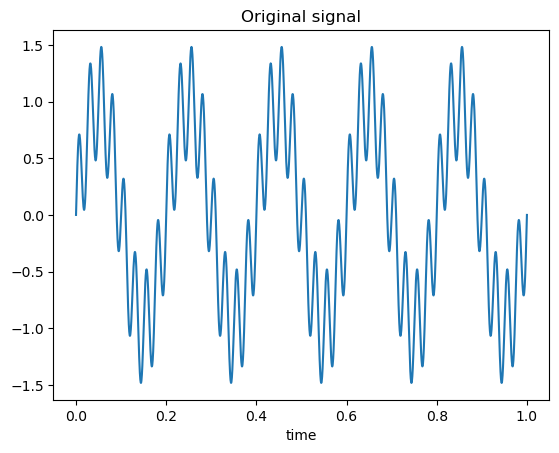

In [7]:
t = np.linspace(0,1,2000)

signal = np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*40*t)

plt.plot(t,signal)
plt.title("Original signal")
plt.xlabel("time")
plt.show()

This signal contains: 5 Hz & 40 Hz.

### Low-Pass Filter
A simple low-pass filter can be simulated by smoothing the signal.


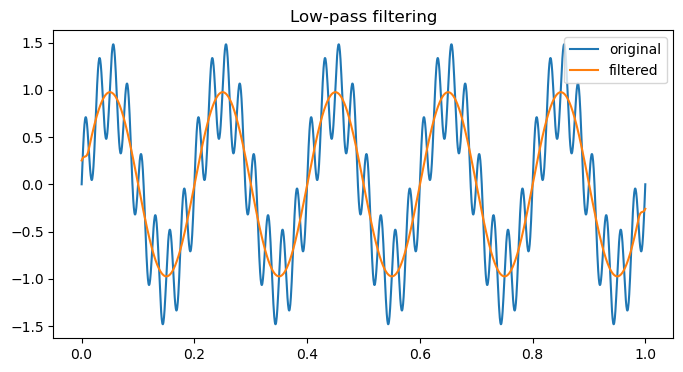

In [8]:
window = np.ones(50)/50
filtered = np.convolve(signal,window,mode='same')

plt.figure(figsize=(8,4))
plt.plot(t,signal,label="original")
plt.plot(t,filtered,label="filtered")
plt.legend()
plt.title("Low-pass filtering")
plt.show()

### Observation
The **high-frequency oscillations disappear.**

The low-frequency component remains.

### Frequency Spectrum

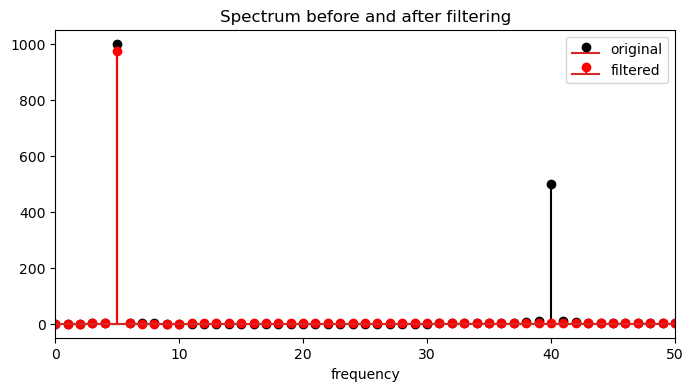

In [9]:
freq = fftfreq(len(t),t[1]-t[0])

S = fft(signal)
Sf = fft(filtered)

plt.figure(figsize=(8,4))
plt.stem(freq[:1000],np.abs(S[:1000]),'k',label="original")
plt.stem(freq[:1000],np.abs(Sf[:1000]),'r',label="filtered")
plt.legend()
plt.title("Spectrum before and after filtering")
plt.xlabel("frequency")
plt.xlim(0,50)
plt.show()

**Filters operate in the frequency domain.**






# 6. Laplace Transform

The **Laplace transform** generalizes the Fourier transform.

It is defined as

$$
X(s) =  \mathcal{L} \{ x(t) \} =
\int_0^\infty x(t)e^{-st}dt
$$

where

$$
s = \sigma + i\omega
$$

Laplace analysis is extremely useful for studying

* **RC circuits**
* **RL circuits**
* **RLC oscillators**
* **control systems**

because it handles **exponential growth and decay** naturally.


# Example: RC Circuit Response

A capacitor charging follows

$$
V(t) = V_0(1-e^{-t/RC})
$$

This exponential behavior is easily analyzed using Laplace transforms.


# 7. Average Value of a Signal

The **average value** of a signal over a period (T) is

$$
\langle f \rangle =
\frac{1}{T}
\int_0^T f(t) dt
$$

Example: sinusoidal signal

$$
f(t) = A\sin(\omega t)
$$

Compute the average.

In [10]:
t = np.linspace(0,2*np.pi,1000)

f = np.sin(t)

print(np.mean(f))

0.0


Result:

Average ≈ **0**

Thus pure oscillations have **zero DC component**.


<div class="alert alert-info">
    
# 8. Exercises

### Exercise 1

Generate the signal

$$
x(t) =
\sin(2\pi 5t)
+
\sin(2\pi 20t)
$$

Plot

* time signal
* frequency spectrum

Identify the frequencies.


### Exercise 2

Add noise to the signal

```python
noise = 0.5*np.random.randn(len(t))
```

Compute the spectrum again.

What changes?


### Exercise 3

Simulate a simple low-pass filter using convolution.

Observe how high frequencies are suppressed.

</div>